In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tracklab import ExperimentReader

# Save figure as svg
# path = Path('../../presentation/public/fig/')
path = Path('./')
# Make sure the directory exists
path.mkdir(parents=True, exist_ok=True)

# Plot config

In [3]:
"""
Script to set up the configurations for the plots.
"""
# Define font sizes
FONTSIZES = {
    'xxs': 4,
    'xs': 6,
    's': 8,
    'm': 10,
    'l': 12,
    'xl': 14,
    'xxl': 16
}

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column

def set_font_sizes(conf='normal', factor=1, sizes=None):
    """
    Set font sizes for plots.
    """
    keys = ['font.size', 'axes.labelsize', 'axes.titlesize',
            'xtick.labelsize', 'ytick.labelsize',
            'legend.fontsize', 'figure.titlesize']
    
    if conf == 'normal':
        sizes = ['m', 'm', 'm', 's', 's', 's', 'l']
    elif conf == 'equal':
        sizes = ['m', 'm', 'm', 'm', 'm', 'm', 'm']
    elif conf == 'tight':
        sizes = ['s', 'm', 'm', 'xs', 'xs', 'xs', 'm']
    elif conf == 'custom':
        if sizes is None:
            raise ValueError("Must specify list of sizes (e.g., ['m', 'm', 'm', 's', 's', 's', 'l'])")
    
    for size, key in zip(sizes, keys):
        plt.rcParams[key] = FONTSIZES[size] * factor


def apply_general_styles():
    """
    Apply general plot styles.
    """
    plt.rcParams.update({
        'mathtext.fontset': 'cm',
        'font.family': 'STIXGeneral',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.dpi': 150,
        'text.usetex': False,
        'text.latex.preamble': r'\usepackage{amsmath,amssymb}'
    })


def create_fig(nrows=1,ncols=1,size='single',w=1.0,h=0.5,layout='constrained',sharex=True,sharey=None,w_ratios=None,h_ratios=None):
    width = single_w if size=='single' else double_w
    figsize = (w*width,h*width)
    fig , axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize,layout=layout,sharex=sharex,sharey=sharey,gridspec_kw={'width_ratios': w_ratios, 'height_ratios': h_ratios})
    return fig , axes

apply_general_styles()
set_font_sizes(conf='tight')

# Code


In [ ]:
# Examples of log files that can be found in the experiment directory

# Example of last 3 lines in a log that finished the training steps
# 2026-09-20 15:16:43,641 - INFO - step 860/860 | loss=4.8519 | top1_accuracy=0.0154
# 2026-09-20 15:16:43,641 - INFO - training done at step 860
# 2026-09-20 15:16:43,641 - INFO - elapsed time = (0.58 min) = (0.01 hr)for 860 steps (40.6 ms/step) = (0.0406 s/step)



# Example of last 3 lines in a log that stopped early due to accuracy > 0.75
# 2026-09-20 15:11:44,643 - INFO - early stop at step 1887: top1_accuracy=0.8060 >= 0.75
# 2026-09-20 15:11:44,644 - INFO - training stopped at step 1887
# 2026-09-20 15:11:44,644 - INFO - elapsed time = (0.59 min) = (0.01 hr)for 1887 steps (18.8 ms/step) = (0.0188 s/step)

# Example of last 3 lines in a log that stopped early due to loss=nan
# 2026-09-20 15:26:57,242 - INFO - step 86/217 | loss=nan | top1_accuracy=0.0000
# 2026-09-20 15:26:57,242 - INFO - training stopped at step 86
# 2026-09-20 15:26:57,243 - INFO - elapsed time = (0.04 min) = (0.00 hr)for 86 steps (26.0 ms/step) = (0.0260 s/step)

## Useful functions

In [4]:
def get_log_info(experiment_dir, run_id):
    """
    Read the last line of the log file manually. The file is located in base_dir/experiment_name/run_id/logs/info.log
    Returns the last line, elapsed time in minutes, and seconds per step.
    """
    log_file_path = Path(experiment_dir)/ run_id / 'logs' / 'info.log'

    last = None
    minutes = None
    sec_per_step = None
    if log_file_path.exists():
        with open(log_file_path, 'r') as f:
            lines = f.read().splitlines()
        last = lines[-1] if lines else None

    if last is not None:
        m = re.search(r"\(([\d.]+) min\).*?\(([\d.]+) s/step\)", last)
        if m:
            minutes, sec_per_step = float(m.group(1)), float(m.group(2))  
    return last, minutes, sec_per_step

In [21]:
experiment_name = 'eta_corners'
base_dir = '../data'
reader = ExperimentReader(experiment_name,base_dir=base_dir)
summary = reader.summarize_runs()


summary['T'] = None
summary['explode'] = None
summary['actual_steps'] = None
summary['elapsed_time_min'] = None
summary['sec_per_step'] = None

for i in range(len(summary)):
    row = summary.iloc[i]
    run_id = row['run_id']
    metrics = reader.load_metrics(run_id).pivot(index='step', columns='metric', values='value').reset_index()
    summary.loc[i,'actual_steps'] = metrics['step'].max()
    # Check for nans in the metrics at the last step and flag the run with explode = True if any nans are found
    if metrics.iloc[-1].isnull().any():
        summary.loc[i,'explode'] = True
    else:
        summary.loc[i,'explode'] = False

    # Read the elapsed time and seconds per step from the log file
    last_line, elapsed_time_min, sec_per_step = get_log_info(base_dir, experiment_name, run_id)
    summary.loc[i,'elapsed_time_min'] = elapsed_time_min
    summary.loc[i,'sec_per_step'] = sec_per_step


    idx_transition = np.where(metrics['top1_accuracy']>0.5)[0]
    if len(idx_transition) > 0:
        T_transition = metrics['step'][idx_transition[0]]
        summary.loc[i,'T'] = T_transition

summary['steps_completed'] = summary['actual_steps'] >= summary['total_steps']

# # Filter out runs that did not reach the transition on a copy dataframe to avoid SettingWithCopyWarning
# filtered_summary = summary[summary['T'].notnull()].copy()


# filtered_summary = filtered_summary[~filtered_summary['run_id'].isin(runs_out)]

# print(filtered_summary[['run_id','vocab_size','d_model','seq_len','T']].tail())

# # Replace nans with 0 in the filtered_summary dataframe
# filtered_summary.fillna(0, inplace=True)

# # Group all runs with same vocab_size & seq_len and compute mean and std of T
# grouped = filtered_summary.groupby(['vocab_size','seq_len','d_model'])['T'].agg(['mean','std']).reset_index()
# print(grouped)

In [23]:
summary['elapsed_time_min'].sum()

72.00000000000001

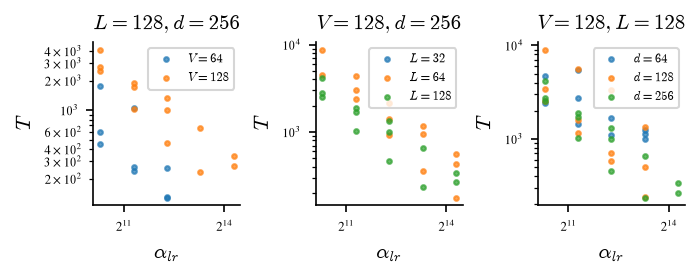

In [50]:
# V128 L128 d256
V_base = 128
L_base = 128
d_base = 256

fig , axes = create_fig(ncols=3,w=1.3)

# Variable V
ax = axes[0]

data = summary[(summary['seq_len']==L_base) & (summary['d_model']==d_base)]
for V in sorted(data['vocab_size'].unique()):
    subset = data[data['vocab_size']==V]
    ax.scatter(subset['alpha_lr'], subset['T'], label=fr'$V={V}$', alpha=0.7,s=5)

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$L={L_base}, d={d_base}$')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend()

# Variable L
ax = axes[1]
data = summary[(summary['vocab_size']==V_base) & (summary['d_model']==d_base)]
for L in sorted(data['seq_len'].unique()):
    subset = data[data['seq_len']==L]
    ax.scatter(subset['alpha_lr'], subset['T'], label=fr'$L={L}$', alpha=0.7,s=5)

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$V={V_base}, d={d_base}$')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend()

# Variable d
ax = axes[2]
data = summary[(summary['vocab_size']==V_base) & (summary['seq_len']==L_base)]
for d in sorted(data['d_model'].unique()):
    subset = data[data['d_model']==d]
    ax.scatter(subset['alpha_lr'], subset['T'], label=fr'$d={d}$', alpha=0.7,s=5)   

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$V={V_base}, L={L_base}$')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend()
    

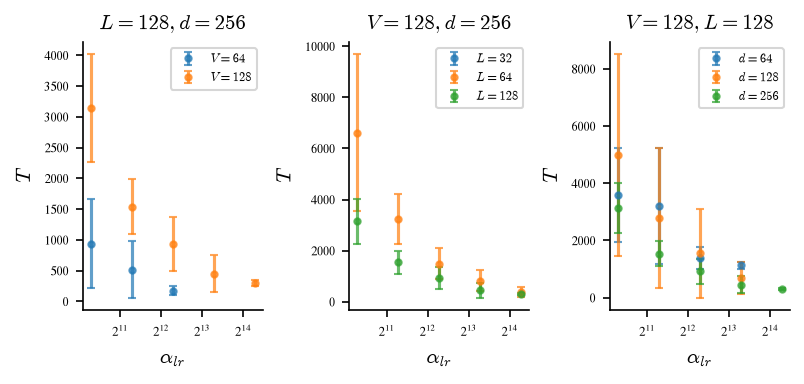

In [55]:
# V128 L128 d256
V_base = 128
L_base = 128
d_base = 256

fig , axes = create_fig(ncols=3,w=1.5,h=0.7)

# Variable V
ax = axes[0]

data = summary[(summary['seq_len']==L_base) & (summary['d_model']==d_base)]
for V in sorted(data['vocab_size'].unique()):
    subset = data[data['vocab_size']==V]
    ax.errorbar(subset['alpha_lr'].unique(), subset.groupby('alpha_lr')['T'].mean(), yerr=subset.groupby('alpha_lr')['T'].std(), label=fr'$V={V}$', alpha=0.7, fmt='o', markersize=3, capsize=2)

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$L={L_base}, d={d_base}$')
ax.set_xscale('log', base=2)
# ax.set_yscale('log')
ax.legend()

# Variable L
ax = axes[1]
data = summary[(summary['vocab_size']==V_base) & (summary['d_model']==d_base)]
for L in sorted(data['seq_len'].unique()):
    subset = data[data['seq_len']==L]
    ax.errorbar(subset['alpha_lr'].unique(), subset.groupby('alpha_lr')['T'].mean(), yerr=subset.groupby('alpha_lr')['T'].std(), label=fr'$L={L}$', alpha=0.7, fmt='o', markersize=3, capsize=2)

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$V={V_base}, d={d_base}$')
ax.set_xscale('log', base=2)
# ax.set_yscale('log')
ax.legend()

# Variable d
ax = axes[2]
data = summary[(summary['vocab_size']==V_base) & (summary['seq_len']==L_base)]
for d in sorted(data['d_model'].unique()):
    subset = data[data['d_model']==d]
    ax.errorbar(subset['alpha_lr'].unique(), subset.groupby('alpha_lr')['T'].mean(), yerr=subset.groupby('alpha_lr')['T'].std(), label=fr'$d={d}$', alpha=0.7, fmt='o', markersize=3, capsize=2)

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$V={V_base}, L={L_base}$')
ax.set_xscale('log', base=2)
# ax.set_yscale('log')
ax.legend()
    

In [47]:
summary['alpha_lr'].unique()

array([ 1250.,  2500.,  5000., 10000., 20000.])

# Sweep

In [2]:
experiment_name = 'scaling_sweep'
base_dir = '../data'
reader = ExperimentReader(experiment_name,base_dir=base_dir)
summary = reader.summarize_runs()


summary['T'] = None
summary['explode'] = None
summary['actual_steps'] = None
summary['elapsed_time_min'] = None
summary['sec_per_step'] = None

for i in range(len(summary)):
    row = summary.iloc[i]
    run_id = row['run_id']
    metrics = reader.load_metrics(run_id).pivot(index='step', columns='metric', values='value').reset_index()
    summary.loc[i,'actual_steps'] = metrics['step'].max()
    # Check for nans in the metrics at the last step and flag the run with explode = True if any nans are found
    if metrics.iloc[-1].isnull().any():
        summary.loc[i,'explode'] = True
    else:
        summary.loc[i,'explode'] = False

    # Read the elapsed time and seconds per step from the log file
    # last_line, elapsed_time_min, sec_per_step = get_log_info(base_dir, experiment_name, run_id)
    # summary.loc[i,'elapsed_time_min'] = elapsed_time_min
    # summary.loc[i,'sec_per_step'] = sec_per_step


    idx_transition = np.where(metrics['top1_accuracy']>0.5)[0]
    if len(idx_transition) > 0:
        T_transition = metrics['step'][idx_transition[0]]
        summary.loc[i,'T'] = T_transition

summary['steps_completed'] = summary['actual_steps'] >= summary['total_steps']

# Filter out runs that did not reach the transition on a copy dataframe to avoid SettingWithCopyWarning
filtered_summary = summary[summary['T'].notnull()].copy()

runs_out = ['run_014']
filtered_summary = filtered_summary[~filtered_summary['run_id'].isin(runs_out)]

print(filtered_summary[['run_id','vocab_size','d_model','seq_len','T']].tail())

# Print filtered_summary sorted by T in descending order
print(filtered_summary[['run_id','vocab_size','d_model','seq_len','T']].sort_values(by='T', ascending=False).head(10))

# Replace nans with 0 in the filtered_summary dataframe
filtered_summary.fillna(0, inplace=True)

# Group all runs with same vocab_size & seq_len and compute mean and std of T
grouped = filtered_summary.groupby(['vocab_size','seq_len','d_model'])['T'].agg(['mean','std']).reset_index()
print(grouped)

     run_id  vocab_size  d_model  seq_len     T
66  run_067         128     1024      128  1233
67  run_068         128     1024      128   740
68  run_069         128     1024      128  2096
69  run_070         128     2048      128   555
70  run_071         128     2048      128  6904
     run_id  vocab_size  d_model  seq_len       T
52  run_053        1024      256      128  290247
25  run_026         512      256      128  184346
24  run_025         512      256      128  147084
54  run_055         512      256      128  126492
53  run_054         512      256      128   88251
50  run_051         512      256      128   69620
49  run_050         256      256      128   18876
48  run_049         256      256      128    9806
31  run_032         128      256       32    7766
70  run_071         128     2048      128    6904
    vocab_size  seq_len  d_model       mean           std
0           32      128      256  83.666667      9.609024
1           64      128      256      338.2   

In [3]:
# Fixed Parameters
d_fixed = 256
V_fixed = 128
L_fixed = 128

rho = 0.2
beta = 0.25
eta_0 = 3500

cnst = 2 * (1 + rho)**2 * np.sqrt(rho * (1 - rho)) / (beta * rho * eta_0)


parameters = {
    'vocab_size': V_fixed,
    'seq_len': L_fixed,
    'd_model': d_fixed
}
names = parameters.keys()


def formated_values(name_variable):
    lb_err = None
    lb_ode = None
    if name_variable == 'd_model':
        title = rf"$(V,L)=({V_fixed},{L_fixed})$"
        xlabel = r"$d$"
        lb_ode = f'Ode'
        lb_err = f'Sim.'
    elif name_variable == 'vocab_size':
        title = rf"$(d,L)=({d_fixed},{L_fixed})$"
        xlabel = r"$V$"
        
    elif name_variable == 'seq_len':
        title = rf"$(d,V)=({d_fixed},{V_fixed})$"
        xlabel = r"$L$"
    else:
        raise ValueError(f"Unknown variable name: {name_variable}")
    return title, xlabel, lb_err, lb_ode


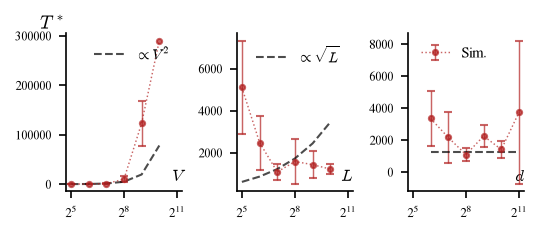

In [9]:

fig , axes = create_fig(ncols=len(names),h=0.4,sharey=False)
for i, name_variable in enumerate(names):
    ax = axes[i]
    title, xlabel , lb_err, lb_ode = formated_values(name_variable)
    if i==0: ax.set_ylabel(r'$T^*$',fontsize=9,loc='top',rotation=0,labelpad=-25)
    # ax.set_title(title, fontsize=8)
    ax.set_xlabel(xlabel,fontsize=8,labelpad=-25,loc='right')

    # Filter dataframe with the other two fixed parameters
    rest_names = [n for n in names if n != name_variable]
    data = grouped[(grouped[rest_names[0]] == parameters[rest_names[0]]) & (grouped[rest_names[1]] == parameters[rest_names[1]])]
    x = data[name_variable].values
    avT = data['mean'].values
    stdT = data['std'].values
    # odeT = np.array(transition_time_ode[name_variable])

    ax.errorbar(x, avT, yerr=stdT, marker='o', label=lb_err, color='firebrick', markersize=2.5, capsize=2,elinewidth=0.7,ls=':',lw=0.7,alpha=0.7)
    # ax.scatter(x, odeT, label=lb_ode, color='k', marker='*', s=15)
        
    
    if name_variable == 'vocab_size':
        T_predict = cnst * (x**2) * np.sqrt(L_fixed)
        ax.plot(x, T_predict, label=r'$\propto V^2$', color='k',linestyle='--', linewidth=1,alpha=0.7)
    if name_variable == 'seq_len':
        T_predict = cnst * (V_fixed**2) * np.sqrt(x)
        ax.plot(x, T_predict, label=r'$\propto \sqrt{L}$',  color='k',linestyle='--', linewidth=1,alpha=0.7)
    if name_variable == 'd_model':
        T_predict = cnst * (V_fixed**2) * np.sqrt(L_fixed)
        ax.plot(x, T_predict*np.ones_like(x),  color='k',linestyle='--', linewidth=1,alpha=0.7)


    ax.legend(fontsize=7,frameon=False)
    ax.set_xscale('log', base=2)
    # ax.set_yscale('log')    
    # ax.set_xlim([2**5/1.5,1.5*2**9])
    # ax.set_ylim(bottom=50,top=5*10**5)
    # ax.set_xticks([2**5, 2**6, 2**7, 2**8, 2**9],[r'$2^5$', None , r'$2^7$', None, r'$2^9$'])
    # if i>0 : ax.set_yticklabels([])

    # fig.text(0.0,0.96,'(b)',fontsize=8)

# save_fig(fig,'time_scales',base_dir='../../Manuscript/figures')


# sweep on $L$ considering constrained attention_1

In [5]:
experiment_name = 'scaling_sweep_tf32'
base_dir = '../data'
reader = ExperimentReader(experiment_name,base_dir=base_dir)
summary = reader.summarize_runs()


summary['T'] = None
summary['explode'] = None
summary['actual_steps'] = None
summary['elapsed_time_min'] = None
summary['sec_per_step'] = None

for i in range(len(summary)):
    row = summary.iloc[i]
    run_id = row['run_id']
    metrics = reader.load_metrics(run_id).pivot(index='step', columns='metric', values='value').reset_index()
    summary.loc[i,'actual_steps'] = metrics['step'].max()
    # Check for nans in the metrics at the last step and flag the run with explode = True if any nans are found
    if metrics.iloc[-1].isnull().any():
        summary.loc[i,'explode'] = True
    else:
        summary.loc[i,'explode'] = False

    # Read the elapsed time and seconds per step from the log file
    # last_line, elapsed_time_min, sec_per_step = get_log_info(base_dir, experiment_name, run_id)
    # summary.loc[i,'elapsed_time_min'] = elapsed_time_min
    # summary.loc[i,'sec_per_step'] = sec_per_step


    idx_transition = np.where(metrics['top1_accuracy']>0.5)[0]
    if len(idx_transition) > 0:
        T_transition = metrics['step'][idx_transition[0]]
        summary.loc[i,'T'] = T_transition

summary['steps_completed'] = summary['actual_steps'] >= summary['total_steps']

# Filter out runs that did not reach the transition on a copy dataframe to avoid SettingWithCopyWarning
filtered_summary = summary[summary['T'].notnull()].copy()

# runs_out = ['run_014']
# filtered_summary = filtered_summary[~filtered_summary['run_id'].isin(runs_out)]

# print(filtered_summary[['run_id','vocab_size','d_model','seq_len','T']].tail())

# Print filtered_summary sorted by T in descending order
# print(filtered_summary[['run_id','vocab_size','d_model','seq_len','T']].sort_values(by='T', ascending=False).head(10))

# Replace nans with 0 in the filtered_summary dataframe
filtered_summary.fillna(0, inplace=True)

# Group all runs with same vocab_size & seq_len and compute mean and std of T
grouped = filtered_summary.groupby(['seq_len'])['T'].agg(['mean','std']).reset_index()
print(grouped)

   seq_len          mean          std
0       64        3610.0          NaN
1      128       8061.35  4133.257569
2      256  10577.166667  8619.788801
3      512   5945.166667  4053.280322
4     1024   5288.666667  1622.051869


<ErrorbarContainer object of 3 artists>

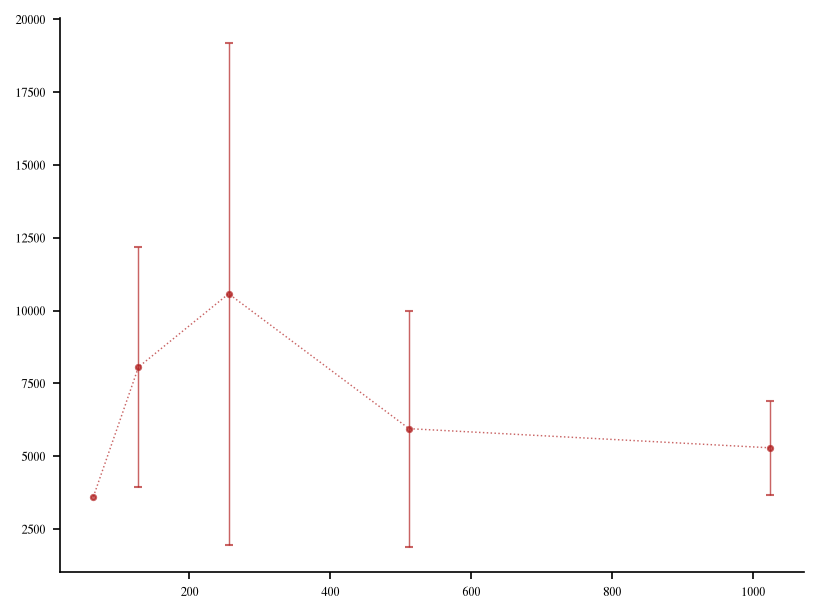

In [6]:
plt.errorbar(grouped['seq_len'], grouped['mean'], yerr=grouped['std'], marker='o', label='Sim.', color='firebrick', markersize=2.5, capsize=2,elinewidth=0.7,ls=':',lw=0.7,alpha=0.7)

# Full comparisson

In [6]:
def analyze(reader: ExperimentReader):

    summary = reader.summarize_runs()

    summary['T'] = None
    summary['explode'] = None
    summary['actual_steps'] = None
    summary['elapsed_time_min'] = None
    summary['sec_per_step'] = None

    for i in range(len(summary)):
        row = summary.iloc[i]
        run_id = row['run_id']
        metrics = reader.load_metrics(run_id).pivot(index='step', columns='metric', values='value').reset_index()
        summary.loc[i,'actual_steps'] = metrics['step'].max()
        # Check for nans in the metrics at the last step and flag the run with explode = True if any nans are found
        if metrics.iloc[-1].isnull().any():
            summary.loc[i,'explode'] = True
        else:
            summary.loc[i,'explode'] = False

        # Read the elapsed time and seconds per step from the log file

        _ , elapsed_time_min, sec_per_step = get_log_info(reader.exp_dir, run_id)
        summary.loc[i,'elapsed_time_min'] = elapsed_time_min
        summary.loc[i,'sec_per_step'] = sec_per_step


        idx_transition = np.where(metrics['top1_accuracy']>0.5)[0]
        if len(idx_transition) > 0:
            T_transition = metrics['step'][idx_transition[0]]
            summary.loc[i,'T'] = T_transition

    summary['steps_completed'] = summary['actual_steps'] >= summary['total_steps']

    # Filter out runs that did not reach the transition on a copy dataframe to avoid SettingWithCopyWarning
    summary = summary[summary['T'].notnull()].copy()

    return summary

In [7]:
experiment_name = 'new_scaling'
base_dir = '../data'
reader = ExperimentReader(experiment_name,base_dir=base_dir)
summary = analyze(reader)

masks = ['causal','prev']
fixed_bs = 512

aggregated_results = {mask1: {} for mask1 in masks}
for mask in masks:
    # Fixed Batch Size
    data = summary[(summary['mask1']==mask) & (summary['batch_size']==fixed_bs)]
    aggregated_results[mask]['fix_bs'] = data.groupby(['seq_len'])['T'].agg(['mean','std']).reset_index()

    # Variable Batch Size
    data = summary[(summary['mask1']==mask) & (summary['batch_size']!=fixed_bs)]
    aggregated_results[mask]['var_bs'] = data.groupby(['seq_len'])['T'].agg(['mean','std']).reset_index()

Text(0.5, 0.98, 'Transition Time $T$ (# SDG steps) vs Sequence Length $L$')

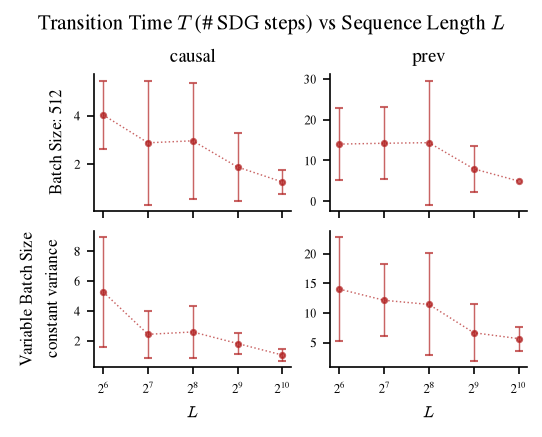

In [8]:


fig , axes = create_fig(2,2,sharey=False,h=0.8)

for i , mask in enumerate(masks):
    for j , bs_type in enumerate(['fix_bs','var_bs']):
        ax = axes[j,i]
        data = aggregated_results[mask][bs_type]
        ax.errorbar(data['seq_len'], data['mean']/1000, yerr=data['std']/1000, marker='o', label=fr'$\mathrm{{{mask}}}$', color='firebrick', markersize=2.5, capsize=2,elinewidth=0.7,ls=':',lw=0.7,alpha=0.7)
        if j==1: ax.set_xlabel(r'$L$',fontsize=8)
        if j==0: ax.set_title(mask,fontsize=9)
        if i==0: ax.set_ylabel(fr'Batch Size: {fixed_bs}' if bs_type=='fix_bs' else f'Variable Batch Size\nconstant variance', fontsize=8)
        ax.set_xscale('log', base=2)
        # ax.set_yscale('log')    

fig.suptitle('Transition Time $T$ (# SDG steps) vs Sequence Length $L$', fontsize=10)